In [2]:
import pandas as pd 
import zipfile 
import json

In [4]:
train_path = "C:/Users/sheik/MS_CLASSES/CSC_528/Penalty_Detection/foul_detection/Images/train.zip"

In [6]:
with zipfile.ZipFile(train_path, 'r') as zip_ref:

    file_list = zip_ref.namelist()

In [8]:
for path in file_list[:20]:  
    print(path)

train/
train/SNMOT-060/
train/SNMOT-060/gt/
train/SNMOT-060/gt/gt.txt
train/SNMOT-060/det/
train/SNMOT-060/det/det.txt
train/SNMOT-060/seqinfo.ini
train/SNMOT-060/gameinfo.ini
train/SNMOT-060/img1/
train/SNMOT-060/img1/000001.jpg
train/SNMOT-060/img1/000002.jpg
train/SNMOT-060/img1/000003.jpg
train/SNMOT-060/img1/000004.jpg
train/SNMOT-060/img1/000005.jpg
train/SNMOT-060/img1/000006.jpg
train/SNMOT-060/img1/000007.jpg
train/SNMOT-060/img1/000008.jpg
train/SNMOT-060/img1/000009.jpg
train/SNMOT-060/img1/000010.jpg
train/SNMOT-060/img1/000011.jpg


In [10]:
gt_path = "train/SNMOT-075/gt/gt.txt" 

with zipfile.ZipFile(train_path, 'r') as zip_ref: 
    with zip_ref.open(gt_path) as file: 
        gt_df = pd.read_csv(file, header=None) 

print(gt_df.head())

   0  1    2    3   4    5  6  7  8  9
0  1  1  942  506  48  138  1 -1 -1 -1
1  2  1  941  506  49  138  1 -1 -1 -1
2  3  1  940  506  50  138  1 -1 -1 -1
3  4  1  939  505  50  138  1 -1 -1 -1
4  5  1  939  505  51  138  1 -1 -1 -1


In [1]:
import zipfile
import os

zip_path = 'C:/Users/sheik/MS_CLASSES/CSC_528/Penalty_Detection/foul_detection/Images/train.zip'  # or the full path
extract_dir = 'C:/Users/sheik/MS_CLASSES/CSC_528/Penalty_Detection/foul_detection/Images/train_unzipped'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)


In [2]:
import zipfile
import os

zip_path = 'C:/Users/sheik/MS_CLASSES/CSC_528/Penalty_Detection/foul_detection/Images/test.zip'  # or the full path
extract_dir = 'C:/Users/sheik/MS_CLASSES/CSC_528/Penalty_Detection/foul_detection/Images/test_unzipped'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)


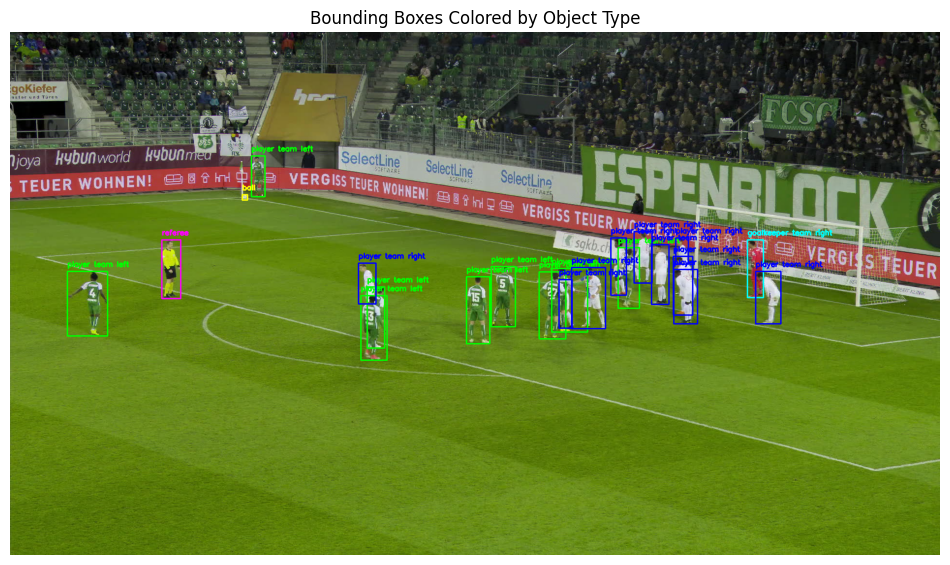

In [12]:
import cv2
import matplotlib.pyplot as plt
import pandas as pd
import configparser

# === Load gt.txt ===
gt_path = r"C:/Users/sheik/MS_CLASSES/CSC_528/Penalty_Detection/foul_detection/Images/train_unzipped/train/SNMOT-075/gt/gt.txt"
gt_df = pd.read_csv(gt_path, header=None)

# === Parse gameinfo.ini to map track_id -> label ===
ini_path = r"C:/Users/sheik/MS_CLASSES/CSC_528/Penalty_Detection/foul_detection/Images/train_unzipped/train/SNMOT-075/gameinfo.ini"
config = configparser.ConfigParser()
config.read(ini_path)

track_id_to_label = {}
for key in config['Sequence']:
    if key.startswith('trackletid_'):
        track_id = int(key.split('_')[1])
        label = config['Sequence'][key].split(';')[0].strip().lower()
        track_id_to_label[track_id] = label

# === Define colors for each label ===
label_colors = {
    'ball': (255, 255, 0),                  # yellow
    'player team left': (0, 255, 0),        # green
    'player team right': (0, 0, 255),       # red
    'referee': (255, 0, 255),               # magenta
    'goalkeeper team left': (0, 128, 128),  # teal
    'goalkeeper team right': (0, 255, 255), # cyan
}


# === Load image ===
img_path = r"C:/Users/sheik/MS_CLASSES/CSC_528/Penalty_Detection/foul_detection/Images/train_unzipped/train/SNMOT-075/img1/000001.jpg"
img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# === Filter to frame 1 only ===
frame_df = gt_df[gt_df[0] == 1]

# === Draw bounding boxes ===
for _, row in frame_df.iterrows():
    track_id = row[1]
    x, y, w, h = row[2:6]
    label = track_id_to_label.get(track_id, 'unknown')
    color = label_colors.get(label, (128, 128, 128))  # gray for unknown
    cv2.rectangle(img, (x, y), (x + w, y + h), color, 2)
    cv2.putText(img, label, (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)

# === Show image ===
plt.figure(figsize=(12, 8))
plt.imshow(img)
plt.axis('off')
plt.title("Bounding Boxes Colored by Object Type")
plt.show()


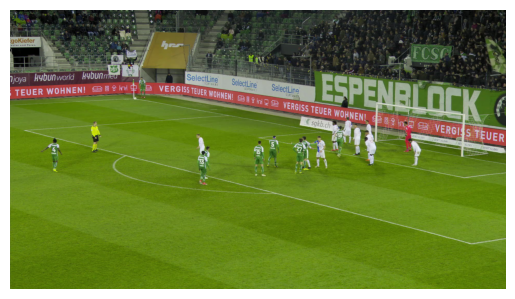

In [6]:
import cv2
import matplotlib.pyplot as plt

img_path = r"C:/Users/sheik/MS_CLASSES/CSC_528/Penalty_Detection/foul_detection/Images/train_unzipped/train/SNMOT-075/img1/000001.jpg"
img = cv2.imread(img_path)
if img is None:
    print("Image not found. Check path:", img_path)
else:
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(img)
    plt.axis('off')
    plt.show()


In [9]:

img_path = r"C:/Users/sheik/MS_CLASSES/CSC_528/Penalty_Detection/foul_detection/Images/train_unzipped/train/SNMOT-075/img1/000001.jpg"
img = cv2.imread(img_path)

if img is None:
    print("OpenCV failed to load the image — possibly corrupted or invalid format.")
else:
    print("Image loaded successfully:", img.shape)

Image loaded successfully: (1080, 1920, 3)


In [11]:
# Column 6 is the class ID
class_counts = gt_df[6].value_counts()
print("Class distribution:\n", class_counts)


Class distribution:
 6
1    14519
Name: count, dtype: int64


In [13]:
import os
import pandas as pd

train_dir = r"C:/Users/sheik/MS_CLASSES/CSC_528/Penalty_Detection/foul_detection/Images/train_unzipped/train"

unique_classes = set()

# Loop through each sequence folder in the train directory
for seq in os.listdir(train_dir):
    seq_path = os.path.join(train_dir, seq)
    if os.path.isdir(seq_path):
        gt_path = os.path.join(seq_path, "gt", "gt.txt")
        if os.path.exists(gt_path):
            # Load ground truth file
            gt_df = pd.read_csv(gt_path, header=None)
            
            print(gt_df)

print("Unique classes found across all train sequences:")
print(unique_classes)


         0   1     2    3    4    5  6  7  8  9
0        1   1   914  855   55  172  1 -1 -1 -1
1        2   1   907  855   67  172  1 -1 -1 -1
2        3   1   901  855   79  172  1 -1 -1 -1
3        4   1   894  854   92  173  1 -1 -1 -1
4        5   1   888  854  104  173  1 -1 -1 -1
...    ...  ..   ...  ...  ...  ... .. .. .. ..
13535  606  26  1850  686   55  128  1 -1 -1 -1
13536  607  26  1864  685   55  128  1 -1 -1 -1
13537  608  26  1871  685   48  128  1 -1 -1 -1
13538  609  26  1889  685   30  128  1 -1 -1 -1
13539  610  26  1889  685   30  128  1 -1 -1 -1

[13540 rows x 10 columns]
         0   1     2    3   4   5  6  7  8  9
0        1   1   537  651  13  13  1 -1 -1 -1
1        2   1   529  650  13  13  1 -1 -1 -1
2        3   1   521  648  13  13  1 -1 -1 -1
3        4   1   513  647  13  13  1 -1 -1 -1
4        5   1   504  646  13  13  1 -1 -1 -1
...    ...  ..   ...  ...  ..  .. .. .. .. ..
11184  746  27  1629  569  15  13  1 -1 -1 -1
11185  747  27  1629  567  15

In [14]:
gt_path = r"C:/Users/sheik/MS_CLASSES/CSC_528/Penalty_Detection/foul_detection/Images/train_unzipped/train/SNMOT-075/gt/gt.txt"
gt_df = pd.read_csv(gt_path, header=None)

# === Parse gameinfo.ini to map track_id -> label ===
ini_path = r"C:/Users/sheik/MS_CLASSES/CSC_528/Penalty_Detection/foul_detection/Images/train_unzipped/train/SNMOT-075/gameinfo.ini"
config = configparser.ConfigParser()
config.read(ini_path)


all_labels = []
train_folder = r"C:/Users/sheik/MS_CLASSES/CSC_528/Penalty_Detection/foul_detection/Images/train_unzipped/train"
# Loop through each sequence folder in train
for seq in os.listdir(train_folder):
    seq_path = os.path.join(train_folder, seq)
    if os.path.isdir(seq_path):
        ini_path = os.path.join(seq_path, "gameinfo.ini") 
        ini_path = ini_path.replace("\\", "/")
        if os.path.exists(ini_path):
            config = configparser.ConfigParser()
            config.read(ini_path)

            # Extract labels from the 'Sequence' section
            if 'Sequence' in config:
                for key in config['Sequence']: 
                   
                    if key.startswith('trackletid_'):
                        label = config['Sequence'][key].split(';')[0].strip().lower() 
                        
                        all_labels.append(label)

# Get unique labels globally
unique_labels = set(all_labels)

print("Unique classes in the train folder:")
print(unique_labels)

Unique classes in the train folder:
{'player team right', 'ball', 'player team left', 'goalkeepers team left', 'referee', 'goalkeeper team right', 'other'}


In [15]:
import configparser
from pathlib import Path
from collections import Counter

train_folder = Path(r"C:/Users/sheik/MS_CLASSES/CSC_528/Penalty_Detection/foul_detection/Images/train_unzipped/train")

# Counter to accumulate all class labels
label_counter = Counter()

for seq_dir in train_folder.iterdir():
    if not seq_dir.is_dir():
        continue

    seqinfo_path = seq_dir / "gameinfo.ini"
    if not seqinfo_path.exists():
        continue

    config = configparser.ConfigParser()
    config.read(seqinfo_path)

    # Parse the tracklet labels in [Sequence]
    if 'Sequence' in config:
        for key, val in config['Sequence'].items():
            if key.startswith("trackletid_"):
                label = val.split(';')[0].strip().lower()
                label_counter[label] += 1

# Print counts of each label
for label, count in label_counter.items():
    print(f"{label}: {count}")


player team left: 575
player team right: 570
referee: 125
ball: 74
goalkeepers team left: 38
goalkeeper team right: 41
other: 4


In [19]:
classes = ['other', 'player team left', 'goalkeepers team left', 'ball', 'goalkeeper team right', 'player team right', 'referee']
class_to_id = {cls_name: idx for idx, cls_name in enumerate(classes)}

print(class_to_id)

{'other': 0, 'player team left': 1, 'goalkeepers team left': 2, 'ball': 3, 'goalkeeper team right': 4, 'player team right': 5, 'referee': 6}


In [21]:
import configparser

def get_tracklet_mapping(ini_path):
    config = configparser.ConfigParser()
    config.read(ini_path)
    
    tracklet_to_label = {}
    for key in config['Sequence']:
        if key.lower().startswith('trackletid_'):
            track_id = int(key.split('_')[1])
            label = config['Sequence'][key].split(';')[0].strip().lower()
            tracklet_to_label[track_id] = label 
    return tracklet_to_label


In [23]:
def convert_bbox_to_yolo(x, y, w, h, img_w, img_h):
    x_center = (x + w / 2) / img_w
    y_center = (y + h / 2) / img_h
    w /= img_w
    h /= img_h
    return x_center, y_center, w, h

In [25]:
base_dir = r"C:/Users/sheik/MS_CLASSES/CSC_528/Penalty_Detection/foul_detection/Images/train_unzipped/train" 
output_base = r"C:/Users/sheik/MS_CLASSES/CSC_528/Penalty_Detection/foul_detection/Images/train_unzipped/yolo_labels"  
img_size = (1080, 1920)
for seq_name in os.listdir(base_dir):  
 
    seq_path = os.path.join(base_dir, seq_name)
    if not os.path.isdir(seq_path):
        continue 
    gt_path = os.path.join(seq_path, "gt", "gt.txt")
    ini_path = os.path.join(seq_path, "gameinfo.ini")
    img_dir = os.path.join(seq_path, "img1")  
    if not os.path.exists(gt_path) or not os.path.exists(ini_path):
        print(f"Skipping {seq_name}, missing gt or ini.")
        continue  
    gt_df = pd.read_csv(gt_path, header=None)  
    #print(img_dir)
    track_id_to_label = get_tracklet_mapping(ini_path) 
    out_seq_dir = os.path.join(output_base, seq_name).replace("\\","/")
    os.makedirs(out_seq_dir, exist_ok=True)   
    for frame_id in sorted(gt_df[0].unique()):
        frame_df = gt_df[gt_df[0] == frame_id]  
        yolo_lines = [] 
        for _, row in frame_df.iterrows(): 
            track_id = row[1]  
            x, y, w, h = row[2:6] 
            label = track_id_to_label.get(track_id, 'unknown')
            if label not in class_to_id: 
                print("does not exist")
                continue 
            class_id = class_to_id[label] 
            x_c, y_c, w_n, h_n = convert_bbox_to_yolo(x, y, w, h, img_size[1], img_size[0])
            yolo_lines.append(f"{class_id} {x_c:.6f} {y_c:.6f} {w_n:.6f} {h_n:.6f}")   
            
        out_path = os.path.join(out_seq_dir, f"{frame_id:06d}.txt")
        with open(out_path, 'w') as f:
            f.write("\n".join(yolo_lines)) 
    print(f"Processed {seq_name}")
        
            
        
    
    
    
    


Processed SNMOT-060
Processed SNMOT-061
Processed SNMOT-062
Processed SNMOT-063
Processed SNMOT-064
Processed SNMOT-065
Processed SNMOT-066
Processed SNMOT-067
Processed SNMOT-068
Processed SNMOT-069
Processed SNMOT-070
Processed SNMOT-071
Processed SNMOT-072
Processed SNMOT-073
Processed SNMOT-074
Processed SNMOT-075
Processed SNMOT-076
Processed SNMOT-077
Processed SNMOT-097
Processed SNMOT-098
Processed SNMOT-099
Processed SNMOT-100
Processed SNMOT-101
Processed SNMOT-102
Processed SNMOT-103
Processed SNMOT-104
Processed SNMOT-105
Processed SNMOT-106
Processed SNMOT-107
Processed SNMOT-108
Processed SNMOT-109
Processed SNMOT-110
Processed SNMOT-111
Processed SNMOT-112
Processed SNMOT-113
Processed SNMOT-114
Processed SNMOT-115
Processed SNMOT-151
Processed SNMOT-152
Processed SNMOT-153
Processed SNMOT-154
Processed SNMOT-155
Processed SNMOT-156
Processed SNMOT-157
Processed SNMOT-158
Processed SNMOT-159
Processed SNMOT-160
Processed SNMOT-161
Processed SNMOT-162
Processed SNMOT-163


In [27]:
def draw_yolo_boxes(img_path, label_path, class_colors=None, class_id_to_label=None):
    img = cv2.imread(img_path)
    if img is None:
        print(f"Could not read image: {img_path}")
        return
    
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w, _ = img.shape

    if not os.path.exists(label_path):
        print(f"No label file for: {img_path}")
        return

    with open(label_path, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) != 5:
                continue
            class_id, x_center, y_center, box_w, box_h = map(float, parts)
            class_id = int(class_id)

            # Convert normalized to pixel coordinates
            x1 = int((x_center - box_w / 2) * w)
            y1 = int((y_center - box_h / 2) * h)
            x2 = int((x_center + box_w / 2) * w)
            y2 = int((y_center + box_h / 2) * h)

            # Get color and label for class_id
            color = class_colors.get(class_id, (255, 255, 255)) if class_colors else (255, 255, 255)
            label = class_id_to_label.get(class_id, str(class_id))

            # Draw box and label
            cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
            cv2.putText(img, label, (x1, y1 - 5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)

    plt.figure(figsize=(10, 8))
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"YOLO Boxes: {os.path.basename(img_path)}")
    plt.show()


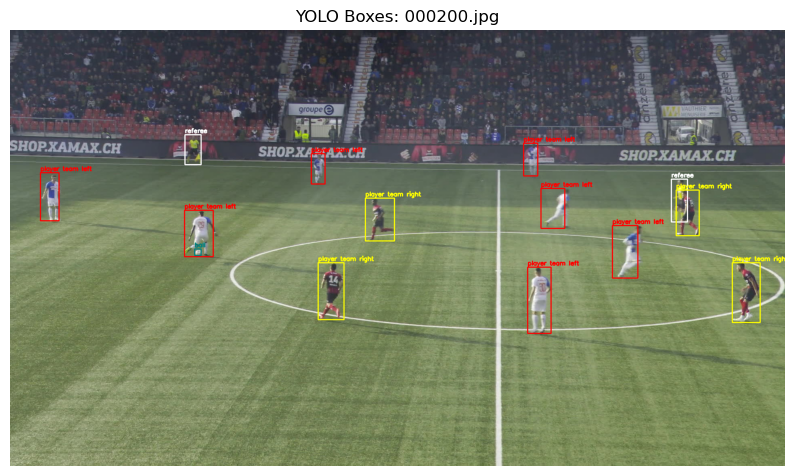

In [29]:
class_id_to_name = {
    0: 'other',
    1: 'player team left',
    2: 'goalkeepers team left',
    3: 'ball',
    4: 'goalkeeper team right',
    5: 'player team right',  
    6: 'referee'
    
}
#{'other': 0, 'player team left': 1, 'goalkeepers team left': 2, 'ball': 3, 'goalkeeper team right': 4, 'player team right': 5, 'referee': 6}

class_colors = {
    0: (0, 255, 0),      # green
    1: (255, 0, 0),      # blue
    2: (255, 0, 255),    # magenta
    3: (0, 128, 128),    # teal
    4: (0, 255, 255),    # cyan
    5: (255, 255, 0),    # yellow
}

img_path = r"C:\Users\sheik\MS_CLASSES\CSC_528\Penalty_Detection\foul_detection\Images\train_unzipped\train\SNMOT-151\img1\000200.jpg"
label_path = r"C:/Users/sheik/MS_CLASSES/CSC_528/Penalty_Detection/foul_detection/Images/train_unzipped/yolo_labels/SNMOT-151/000200.txt" 



draw_yolo_boxes(img_path, label_path, class_colors, class_id_to_name)



In [31]:
import zipfile
import os

zip_path = 'C:/Users/sheik/MS_CLASSES/CSC_528/Penalty_Detection/foul_detection/Images/test.zip'  # or the full path
extract_dir = 'C:/Users/sheik/MS_CLASSES/CSC_528/Penalty_Detection/foul_detection/Images/test_unzipped'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)


KeyboardInterrupt: 

In [40]:
base_dir = r"C:/Users/sheik/MS_CLASSES/CSC_528/Penalty_Detection/foul_detection/Images/test_unzipped/test" 
output_base = r"C:/Users/sheik/MS_CLASSES/CSC_528/Penalty_Detection/foul_detection/Images/test_unzipped/yolo_labels"  
img_size = (1080, 1920)
for seq_name in os.listdir(base_dir):  
 
    seq_path = os.path.join(base_dir, seq_name)
    if not os.path.isdir(seq_path):
        continue 
    gt_path = os.path.join(seq_path, "gt", "gt.txt")
    ini_path = os.path.join(seq_path, "gameinfo.ini")
    img_dir = os.path.join(seq_path, "img1")  
    if not os.path.exists(gt_path) or not os.path.exists(ini_path):
        print(f"Skipping {seq_name}, missing gt or ini.")
        continue  
    gt_df = pd.read_csv(gt_path, header=None)  
    #print(img_dir)
    track_id_to_label = get_tracklet_mapping(ini_path) 
    out_seq_dir = os.path.join(output_base, seq_name).replace("\\","/")
    os.makedirs(out_seq_dir, exist_ok=True)   
    for frame_id in sorted(gt_df[0].unique()):
        frame_df = gt_df[gt_df[0] == frame_id]  
        yolo_lines = [] 
        for _, row in frame_df.iterrows(): 
            track_id = row[1]  
            x, y, w, h = row[2:6] 
            label = track_id_to_label.get(track_id, 'unknown')
            if label not in class_to_id: 
                print("does not exist")
                continue 
            class_id = class_to_id[label] 
            x_c, y_c, w_n, h_n = convert_bbox_to_yolo(x, y, w, h, img_size[1], img_size[0])
            yolo_lines.append(f"{class_id} {x_c:.6f} {y_c:.6f} {w_n:.6f} {h_n:.6f}")   
            
        out_path = os.path.join(out_seq_dir, f"{frame_id:06d}.txt")
        with open(out_path, 'w') as f:
            f.write("\n".join(yolo_lines)) 
    print(f"Processed {seq_name}")
        
            
        
    
    
    
    


Processed SNMOT-116
Processed SNMOT-117
Processed SNMOT-118
Processed SNMOT-119
Processed SNMOT-120
Processed SNMOT-121
Processed SNMOT-122
Processed SNMOT-123
Processed SNMOT-124
Processed SNMOT-125
Processed SNMOT-126
Processed SNMOT-127
Processed SNMOT-128
Processed SNMOT-129
Processed SNMOT-130
Processed SNMOT-131
Processed SNMOT-132
Processed SNMOT-133
Processed SNMOT-134
Processed SNMOT-135
Processed SNMOT-136
Processed SNMOT-137
Processed SNMOT-138
Processed SNMOT-139
Processed SNMOT-140
Processed SNMOT-141
Processed SNMOT-142
Processed SNMOT-143
Processed SNMOT-144
Processed SNMOT-145
Processed SNMOT-146
Processed SNMOT-147
Processed SNMOT-148
Processed SNMOT-149
Processed SNMOT-150
Processed SNMOT-187
Processed SNMOT-188
Processed SNMOT-189
Processed SNMOT-190
Processed SNMOT-191
Processed SNMOT-192
Processed SNMOT-193
Processed SNMOT-194
Processed SNMOT-195
Processed SNMOT-196
Processed SNMOT-197
Processed SNMOT-198
Processed SNMOT-199
Processed SNMOT-200


In [42]:
import os
import shutil

base_img_dir = r"C:/Users/sheik/MS_CLASSES/CSC_528/Penalty_Detection/foul_detection/Images/test_unzipped/test"
base_label_dir = r"C:/Users/sheik/MS_CLASSES/CSC_528/Penalty_Detection/foul_detection/Images/test_unzipped/yolo_labels"
output_combined = r"C:/Users/sheik/MS_CLASSES/CSC_528/Penalty_Detection/foul_detection/Images/combined_test"

img_out_dir = os.path.join(output_combined, "images")
label_out_dir = os.path.join(output_combined, "labels")

os.makedirs(img_out_dir, exist_ok=True)
os.makedirs(label_out_dir, exist_ok=True)

for seq_name in os.listdir(base_img_dir):
    seq_path = os.path.join(base_img_dir, seq_name)
    img_seq_dir = os.path.join(seq_path, "img1")
    label_seq_dir = os.path.join(base_label_dir, seq_name)
    
    if not os.path.isdir(img_seq_dir) or not os.path.isdir(label_seq_dir):
        continue
    
    for img_file in sorted(os.listdir(img_seq_dir)):
        if not img_file.endswith('.jpg'):
            continue
        
        frame_id = os.path.splitext(img_file)[0]  # e.g., "000001"
        new_name = f"{seq_name}_{frame_id}"       # e.g., "SNMOT_01_000001" 
        

        src_img = os.path.join(img_seq_dir, img_file)
        dst_img = os.path.join(img_out_dir, f"{new_name}.jpg")
        shutil.copy2(src_img, dst_img)

        label_file = os.path.join(label_seq_dir, f"{frame_id}.txt")
        dst_label = os.path.join(label_out_dir, f"{new_name}.txt")

        if os.path.exists(label_file):
            shutil.copy2(label_file, dst_label)
        else:
            print(f"Label missing for {new_name}")

print("✅ Combined dataset created successfully.")


✅ Combined dataset created successfully.


In [20]:
import os
import pandas as pd
import configparser

# Define base directory
base_dir = r"C:/Users/sheik/MS_CLASSES/CSC_528/Penalty_Detection/foul_detection/Images/train_unzipped/train"

# Helper: map track IDs to labels from gameinfo.ini
def get_tracklet_mapping(ini_path):
    config = configparser.ConfigParser()
    config.read(ini_path)
    tracklet_to_label = {}
    for key in config['Sequence']:
        if key.lower().startswith('trackletid_'):
            track_id = int(key.split('_')[1])
            label = config['Sequence'][key].split(';')[0].strip().lower()
            tracklet_to_label[track_id] = label
    return tracklet_to_label

# Initialize totals
total_ball_width = 0
total_ball_height = 0
ball_count = 0

# Loop through sequences
for seq_name in os.listdir(base_dir):
    seq_path = os.path.join(base_dir, seq_name)
    gt_path = os.path.join(seq_path, "gt", "gt.txt")
    ini_path = os.path.join(seq_path, "gameinfo.ini")

    if not os.path.exists(gt_path) or not os.path.exists(ini_path):
        print(f"Skipping {seq_name} (missing gt.txt or gameinfo.ini)")
        continue

    gt_df = pd.read_csv(gt_path, header=None)
    track_id_to_label = get_tracklet_mapping(ini_path)

    # Filter for ball objects
    for _, row in gt_df.iterrows():
        track_id = row[1]
        x, y, w, h = row[2:6]
        label = track_id_to_label.get(track_id, None)
        if label == 'ball':
            total_ball_width += w
            total_ball_height += h
            ball_count += 1

# Final average
if ball_count > 0:
    avg_w = total_ball_width / ball_count
    avg_h = total_ball_height / ball_count
    print(f"\n🎯 Average 'ball' bounding box size:")
    print(f"Width:  {avg_w:.2f} px")
    print(f"Height: {avg_h:.2f} px")
else:
    print("No 'ball' bounding boxes found.")



🎯 Average 'ball' bounding box size:
Width:  15.12 px
Height: 14.09 px
